<a href="https://colab.research.google.com/github/Dassann/E1_DEEP_LEARNING_701D_ValentinaCisterna_LucasContreras/blob/main/E1_DEEP_LEARNING_ValentinaCisterna_LucasContreras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°1 - Fundamentos de Deep Learning

## Clasificación de imágenes con una red neuronal MLP usando CIFAR-10

### Integrantes:
- Valentina Cisterna
- Lucas Contreras
- Jorge Lorca

## Introducción

En este trabajo se implementará una red neuronal artificial multicapa (MLP) para resolver un problema de clasificación de imágenes utilizando el dataset CIFAR-10.

El objetivo es aplicar los fundamentos de Deep Learning mediante la carga y preprocesamiento de datos, construcción del modelo, entrenamiento, ajuste de hiperparámetros y evaluación del desempeño utilizando métricas como accuracy, precision, recall y F1-score.

Además, se analizará el impacto de distintas configuraciones del modelo, incluyendo funciones de activación, optimizadores, tamaño de batch y técnicas de regularización como dropout y batch normalization, con el fin de comparar resultados y justificar técnicamente las decisiones tomadas.

In [40]:
# Importación de librerías principales

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

## Carga del dataset

Se utilizará el dataset CIFAR-10, el cual contiene 60.000 imágenes a color de tamaño 32x32 píxeles, distribuidas en 10 categorías.

Estas categorías corresponden a objetos comunes como avión, automóvil, pájaro, gato, perro, barco, entre otros.

El conjunto de datos se divide en:
- 50.000 imágenes para entrenamiento
- 10.000 imágenes para prueba

Este dataset es apropiado para problemas de clasificación multiclase y permite evaluar el comportamiento de una red neuronal MLP frente a imágenes pequeñas.

In [41]:
# Carga de CIFAR-10

(imgs_train, labs_train), (imgs_test, labs_test) = cifar10.load_data()

print("Forma de imgs_train:", imgs_train.shape)
print("Forma de labs_train:", labs_train.shape)
print("Forma de imgs_test :", imgs_test.shape)
print("Forma de labs_test :", labs_test.shape)

Forma de imgs_train: (50000, 32, 32, 3)
Forma de labs_train: (50000, 1)
Forma de imgs_test : (10000, 32, 32, 3)
Forma de labs_test : (10000, 1)


In [42]:
# Nombres de las clases del dataset

nombres = ['avión', 'auto', 'pájaro', 'gato', 'venado',
           'perro', 'rana', 'caballo', 'barco', 'camión']

## Exploración visual del dataset

Antes de entrenar el modelo, es importante explorar visualmente algunas imágenes del dataset para comprender mejor el tipo de datos con los que se trabajará.

Esta etapa permite verificar que las imágenes fueron cargadas correctamente y observar ejemplos reales de las distintas clases.

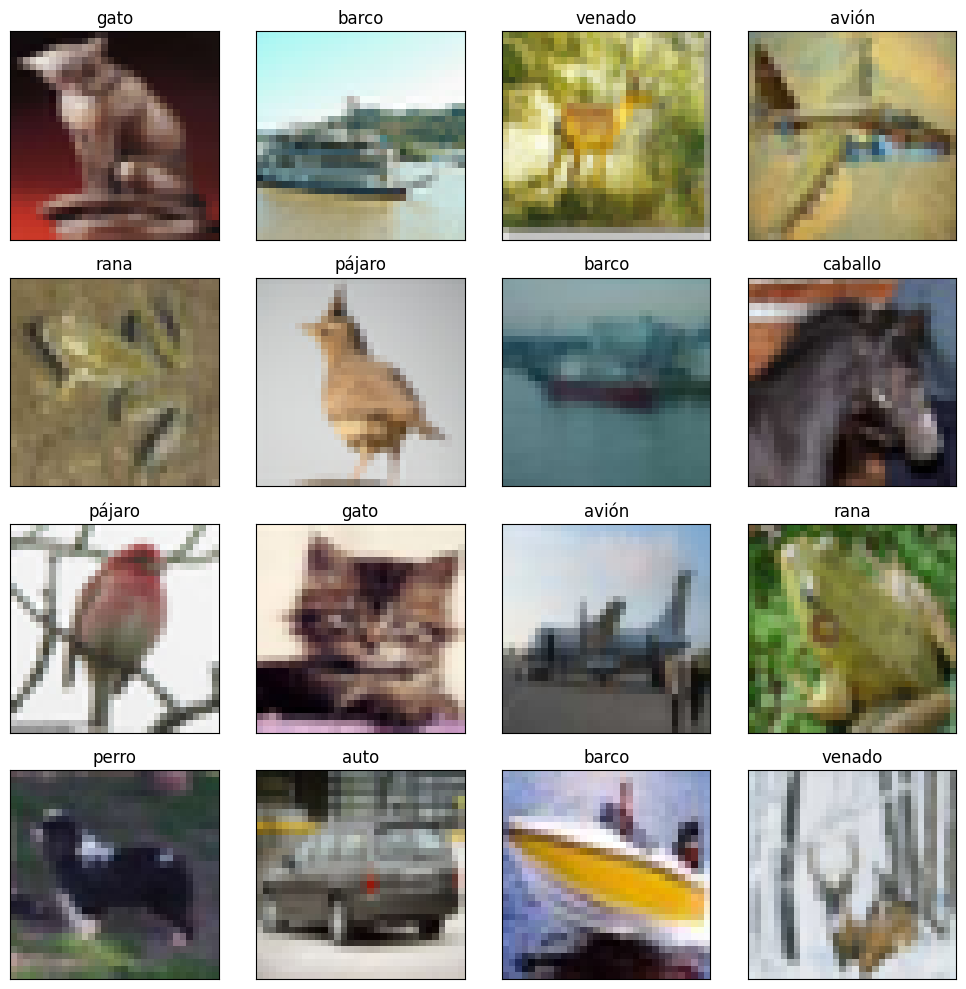

In [43]:
# Visualización de algunas imágenes del conjunto de prueba

h = 4
w = 4

fig, axs = plt.subplots(h, w, figsize=(10, 10))

for i in range(h):
    for j in range(w):
        ex = np.random.randint(len(imgs_test))
        axs[i, j].imshow(imgs_test[ex])
        axs[i, j].set_title(nombres[labs_test[ex][0]])
        axs[i, j].grid(False)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])

plt.tight_layout()
plt.show()

## Preprocesamiento de los datos

Para utilizar las imágenes en una red neuronal multicapa (MLP), es necesario aplicar un proceso de preprocesamiento.

Las imágenes originales tienen forma 32x32x3, pero una MLP trabaja con vectores de entrada. Por esta razón, cada imagen será transformada en un vector de 3072 valores.

Además, se realizará una normalización de los píxeles dividiendo por 255, con el fin de llevar los datos al rango [0,1]. Esto facilita el entrenamiento y mejora la estabilidad numérica del modelo.

Finalmente, las etiquetas se convertirán a formato one-hot encoding para que puedan utilizarse correctamente en una clasificación multiclase con una capa de salida softmax.

In [44]:
# Preprocesamiento de los datos

X_train = imgs_train.reshape(50000, 32 * 32 * 3).astype("float32")
X_test = imgs_test.reshape(10000, 32 * 32 * 3).astype("float32")

X_train = X_train / 255.0
X_test = X_test / 255.0

Y_train = to_categorical(labs_train, 10)
Y_test = to_categorical(labs_test, 10)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test :", X_test.shape)
print("Forma de Y_train:", Y_train.shape)
print("Forma de Y_test :", Y_test.shape)

Forma de X_train: (50000, 3072)
Forma de X_test : (10000, 3072)
Forma de Y_train: (50000, 10)
Forma de Y_test : (10000, 10)


In [45]:
# Variables principales del problema

M_train = X_train.shape[0]
M_test = X_test.shape[0]
N = X_train.shape[1]
C = Y_train.shape[1]

print("Cantidad de ejemplos de entrenamiento:", M_train)
print("Cantidad de ejemplos de prueba:", M_test)
print("Cantidad de entradas por ejemplo:", N)
print("Cantidad de clases:", C)

Cantidad de ejemplos de entrenamiento: 50000
Cantidad de ejemplos de prueba: 10000
Cantidad de entradas por ejemplo: 3072
Cantidad de clases: 10


## Definición del modelo base

Se construirá un modelo base de tipo MLP, que servirá como referencia inicial para evaluar el desempeño del sistema.

Este modelo incluirá:
- Capa de entrada de 3072 valores
- Dos capas ocultas densas
- Función de activación ReLU en las capas ocultas
- Capa de salida con 10 neuronas y función softmax

La función softmax se utiliza porque el problema corresponde a una clasificación multiclase, mientras que la función de pérdida categorical_crossentropy permite comparar la distribución predicha con la distribución real de las clases.

In [46]:
# Función para crear modelos MLP con distintos hiperparámetros

def crear_modelo(units1=512, units2=256, activation='relu',
                 optimizer='adam', loss='categorical_crossentropy',
                 dropout_rate=0.0, batch_norm=False):

    model = keras.Sequential()
    model.add(layers.Input(shape=(N,)))
    model.add(layers.Dense(units1, activation=activation))

    if batch_norm:
        model.add(layers.BatchNormalization())
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(units2, activation=activation))

    if batch_norm:
        model.add(layers.BatchNormalization())
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(C, activation='softmax'))

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [47]:
# Creación del modelo base

np.random.seed(30)
tf.random.set_seed(30)

modelo_base = crear_modelo(
    units1=512,
    units2=256,
    activation='relu',
    optimizer='adam',
    loss='categorical_crossentropy',
    dropout_rate=0.0,
    batch_norm=False
)

modelo_base.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del modelo base

Se entrenará el modelo base utilizando:
- 20 épocas
- batch size de 128
- conjunto de validación durante el entrenamiento

El uso de un conjunto de validación permite monitorear el comportamiento del modelo y detectar posibles signos de overfitting.

In [48]:
# Entrenamiento del modelo base

hist_base = modelo_base.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3123 - loss: 1.9282 - val_accuracy: 0.3402 - val_loss: 1.8193
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3880 - loss: 1.7096 - val_accuracy: 0.3949 - val_loss: 1.6917
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4208 - loss: 1.6204 - val_accuracy: 0.4124 - val_loss: 1.6460
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4423 - loss: 1.5610 - val_accuracy: 0.4142 - val_loss: 1.6370
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4583 - loss: 1.5210 - val_accuracy: 0.4429 - val_loss: 1.5708
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4730 - loss: 1.4810 - val_accuracy: 0.4513 - val_loss: 1.5637
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4793 - loss: 1.4528 - val_accuracy: 0.4598 - val_loss: 1.5275
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4961 - loss: 1.4196 - val_accuracy: 0

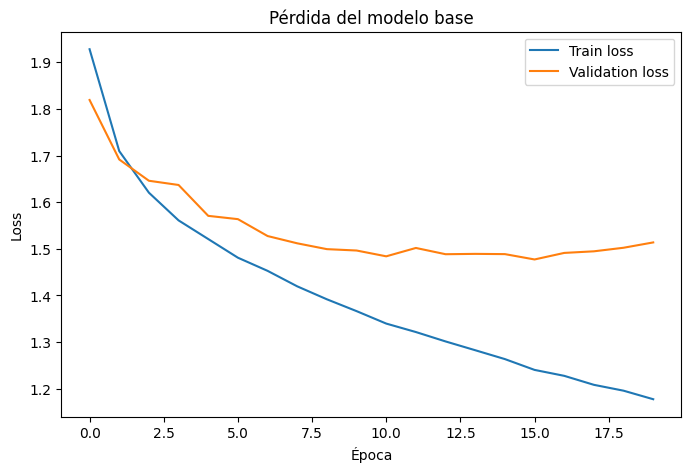

In [49]:
# Gráfico de pérdida del modelo base

plt.figure(figsize=(8,5))
plt.plot(hist_base.history['loss'], label='Train loss')
plt.plot(hist_base.history['val_loss'], label='Validation loss')
plt.title('Pérdida del modelo base')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

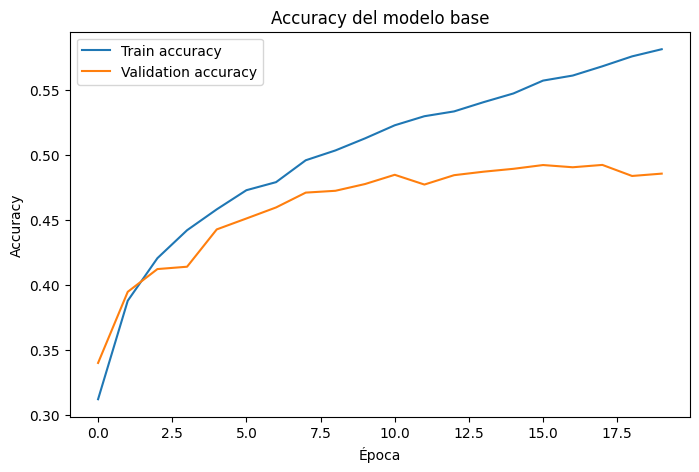

In [50]:
# Gráfico de accuracy del modelo base

plt.figure(figsize=(8,5))
plt.plot(hist_base.history['accuracy'], label='Train accuracy')
plt.plot(hist_base.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy del modelo base')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Evaluación del modelo base

Una vez entrenado el modelo, se evaluará su desempeño utilizando el conjunto de prueba.

Se calcularán las métricas solicitadas:
- Accuracy
- Precision
- Recall
- F1-score

Además, se presentará una matriz de confusión y un reporte de clasificación para observar en detalle el comportamiento del modelo en cada categoría.

In [51]:
# Evaluación del modelo base

y_pred_prob = modelo_base.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = labs_test.flatten()

accuracy = np.mean(y_pred == y_true)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.4954
Precision: 0.4879663868612298
Recall   : 0.4954
F1-score : 0.4863078585482119


In [52]:
# Cuadro resumen de métricas del modelo base

df_metricas_base = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Valor': [accuracy, precision, recall, f1]
})

df_metricas_base

,Métrica,Valor
0,Accuracy,0.495400
1,Precision,0.487966
2,Recall,0.495400
3,F1-score,0.486308


In [53]:
# Reporte de clasificación

print(classification_report(y_true, y_pred, target_names=nombres, zero_division=0))

              precision    recall  f1-score   support

       avión       0.52      0.55      0.53      1000
        auto       0.62      0.60      0.61      1000
      pájaro       0.39      0.32      0.35      1000
        gato       0.37      0.22      0.28      1000
      venado       0.43      0.48      0.45      1000
       perro       0.43      0.34      0.38      1000
        rana       0.50      0.58      0.54      1000
     caballo       0.47      0.65      0.54      1000
       barco       0.57      0.66      0.61      1000
      camión       0.57      0.56      0.56      1000

    accuracy                           0.50     10000
   macro avg       0.49      0.50      0.49     10000
weighted avg       0.49      0.50      0.49     10000



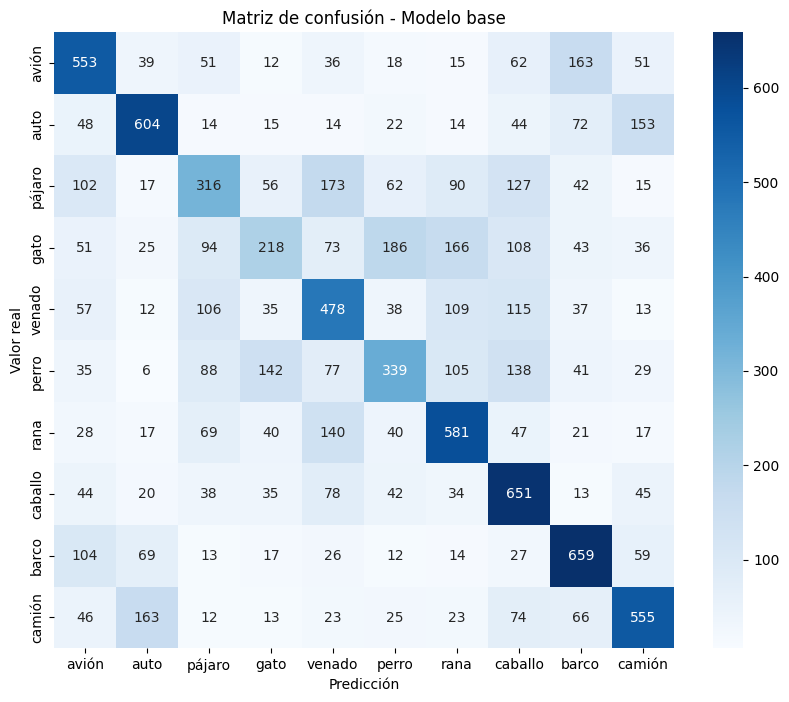

In [54]:
# Matriz de confusión

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres, yticklabels=nombres)
plt.title("Matriz de confusión - Modelo base")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Experimentos controlados

De acuerdo con la pauta, se realizarán experimentos controlados variando un parámetro a la vez, manteniendo constantes los demás.

Esto permitirá analizar el impacto de:
- la función de activación
- el optimizador
- el tamaño del batch
- las técnicas de regularización y normalización

Cada experimento será evaluado con las mismas métricas para asegurar una comparación justa y confiable.

In [55]:
# Lista para guardar resultados de todos los experimentos

resultados = []
historiales = {}

In [56]:
# Función para entrenar y evaluar distintos experimentos

def entrenar_y_evaluar(nombre_experimento,
                       units1=512,
                       units2=256,
                       activation='relu',
                       optimizer='adam',
                       loss='categorical_crossentropy',
                       batch_size=128,
                       epochs=15,
                       dropout_rate=0.0,
                       batch_norm=False):

    np.random.seed(30)
    tf.random.set_seed(30)

    model = crear_modelo(
        units1=units1,
        units2=units2,
        activation=activation,
        optimizer=optimizer,
        loss=loss,
        dropout_rate=dropout_rate,
        batch_norm=batch_norm
    )

    history = model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = labs_test.flatten()

    acc = np.mean(y_pred == y_true)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1v = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    resultados.append({
        'Experimento': nombre_experimento,
        'Activación': activation,
        'Optimizador': optimizer,
        'Loss': loss,
        'Batch size': batch_size,
        'Dropout': dropout_rate,
        'BatchNorm': batch_norm,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1v
    })

    historiales[nombre_experimento] = history

    return model, history

## Estrategia de validación

Para evaluar el desempeño del modelo se utilizó un conjunto de validación a través del parámetro `validation_data`.

No se aplicó validación cruzada completa (k-fold), debido a que el entrenamiento de múltiples modelos sobre el dataset CIFAR-10 implica un alto costo computacional.

En su lugar, se optó por mantener una partición fija de datos de entrenamiento y validación, lo que permite comparar de forma consistente los distintos experimentos realizados.

## Experimento 1: comparación de funciones de activación

En este experimento se analizará el efecto de distintas funciones de activación en el rendimiento del modelo:
- ReLU
- Sigmoid
- Tanh

Se mantendrán constantes el resto de los parámetros para que el análisis sea controlado y válido.

In [57]:
# Experimento con distintas funciones de activación
# Se mantiene fijo: optimizer='adam', batch_size=128, sin regularización

modelo_relu, hist_relu = entrenar_y_evaluar(
    nombre_experimento='Activación ReLU',
    activation='relu',
    optimizer='adam',
    batch_size=128,
    dropout_rate=0.0,
    batch_norm=False
)

modelo_sigmoid, hist_sigmoid = entrenar_y_evaluar(
    nombre_experimento='Activación Sigmoid',
    activation='sigmoid',
    optimizer='adam',
    batch_size=128,
    dropout_rate=0.0,
    batch_norm=False
)

modelo_tanh, hist_tanh = entrenar_y_evaluar(
    nombre_experimento='Activación Tanh',
    activation='tanh',
    optimizer='adam',
    batch_size=128,
    dropout_rate=0.0,
    batch_norm=False
)

## Experimento 2: comparación de optimizadores

En esta prueba se comparará el desempeño del modelo utilizando dos optimizadores distintos:
- SGD
- Adam

La finalidad es observar cuál de ellos permite una mejor convergencia y un mejor resultado final.

In [58]:
# Experimento con distintos optimizadores
# Se mantiene fijo: activation='relu', batch_size=64, sin regularización

modelo_sgd, hist_sgd = entrenar_y_evaluar(
    nombre_experimento='Optimizador SGD',
    activation='relu',
    optimizer='sgd',
    batch_size=64,
    dropout_rate=0.0,
    batch_norm=False
)

modelo_adam, hist_adam = entrenar_y_evaluar(
    nombre_experimento='Optimizador Adam',
    activation='relu',
    optimizer='adam',
    batch_size=64,
    dropout_rate=0.0,
    batch_norm=False
)

## Experimento 3: comparación de tamaño de batch

Ahora se analizará el impacto del tamaño del batch en el entrenamiento del modelo.

Se probarán tres valores:
- 64
- 128
- 256

Esto permitirá observar diferencias en estabilidad, velocidad de convergencia y desempeño final.

In [59]:
# Experimento con distintos batch size
# Se mantiene fijo: activation='tanh', optimizer='adam', sin regularización

modelo_b64, hist_b64 = entrenar_y_evaluar(
    nombre_experimento='Batch 64',
    activation='tanh',
    optimizer='adam',
    batch_size=64,
    dropout_rate=0.0,
    batch_norm=False
)

modelo_b128, hist_b128 = entrenar_y_evaluar(
    nombre_experimento='Batch 128',
    activation='tanh',
    optimizer='adam',
    batch_size=128,
    dropout_rate=0.0,
    batch_norm=False
)

modelo_b256, hist_b256 = entrenar_y_evaluar(
    nombre_experimento='Batch 256',
    activation='tanh',
    optimizer='adam',
    batch_size=256,
    dropout_rate=0.0,
    batch_norm=False
)

## Experimento 4: regularización y normalización

Para evitar overfitting y mejorar la estabilidad del entrenamiento, se comparará:

- un modelo sin regularización
- un modelo con dropout y batch normalization

Estas técnicas son recomendadas como buenas prácticas en la construcción de modelos de Deep Learning.

In [60]:
# Comparación con y sin técnicas de optimización
# Se mantiene fijo: activation='relu', optimizer='adam', batch_size=256

modelo_sin_opt, hist_sin_opt = entrenar_y_evaluar(
    nombre_experimento='Sin regularización',
    activation='relu',
    optimizer='adam',
    batch_size=256,
    dropout_rate=0.0,
    batch_norm=False
)

modelo_con_opt, hist_con_opt = entrenar_y_evaluar(
    nombre_experimento='Con dropout y batchnorm',
    activation='relu',
    optimizer='adam',
    batch_size=256,
    dropout_rate=0.3,
    batch_norm=True
)

## Nota metodológica sobre los experimentos

Los experimentos fueron diseñados siguiendo una estrategia de comparación controlada, en la cual se modifica un solo parámetro por grupo de pruebas mientras los demás se mantienen constantes.

De esta forma, fue posible analizar por separado el impacto de:
- la función de activación,
- el optimizador,
- el tamaño de batch,
- y las técnicas de regularización.

Este enfoque permite realizar comparaciones más justas y justificar técnicamente el efecto de cada decisión de configuración sobre el desempeño del modelo.

## Tabla comparativa de resultados

A continuación se presenta una tabla resumen con los resultados de los distintos experimentos realizados.

Esta comparación permite identificar qué configuraciones obtuvieron mejor desempeño y justificar técnicamente la elección de la mejor alternativa.

In [61]:
# Tabla comparativa final de experimentos

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='Accuracy', ascending=False)
df_resultados

,Experimento,Activación,Optimizador,Loss,Batch size,Dropout,BatchNorm,Accuracy,Precision,Recall,F1-score
3,Optimizador SGD,relu,sgd,categorical_crossentropy,64,0.0,False,0.4928,0.500666,0.4928,0.485784
8,Sin regularización,relu,adam,categorical_crossentropy,256,0.0,False,0.4863,0.489559,0.4863,0.476987
4,Optimizador Adam,relu,adam,categorical_crossentropy,64,0.0,False,0.4806,0.475034,0.4806,0.468319
0,Activación ReLU,relu,adam,categorical_crossentropy,128,0.0,False,0.4797,0.490577,0.4797,0.473967
1,Activación Sigmoid,sigmoid,adam,categorical_crossentropy,128,0.0,False,0.4692,0.466534,0.4692,0.451471
9,Con dropout y batchnorm,relu,adam,categorical_crossentropy,256,0.3,True,0.4681,0.498592,0.4681,0.462707
7,Batch 256,tanh,adam,categorical_crossentropy,256,0.0,False,0.4533,0.445026,0.4533,0.440254
2,Activación Tanh,tanh,adam,categorical_crossentropy,128,0.0,False,0.4282,0.435053,0.4282,0.418914
6,Batch 128,tanh,adam,categorical_crossentropy,128,0.0,False,0.4200,0.415704,0.4200,0.401808
5,Batch 64,tanh,adam,categorical_crossentropy,64,0.0,False,0.3805,0.375012,0.3805,0.352972


## Selección del mejor modelo

A partir de la tabla comparativa y los gráficos anteriores, se seleccionará el modelo con mejor desempeño general.

La elección no se basará únicamente en el accuracy, sino también en métricas como precision, recall y F1-score, ya que estas entregan una visión más completa del comportamiento del modelo.

Además, se considerará la estabilidad observada durante el entrenamiento y la capacidad de generalización sobre el conjunto de prueba.

In [62]:
df_resultados = df_resultados.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

mejor_fila = df_resultados.iloc[0]
nombre_mejor_modelo = mejor_fila['Experimento']

print("Mejor modelo:", nombre_mejor_modelo)

Mejor modelo: Optimizador SGD


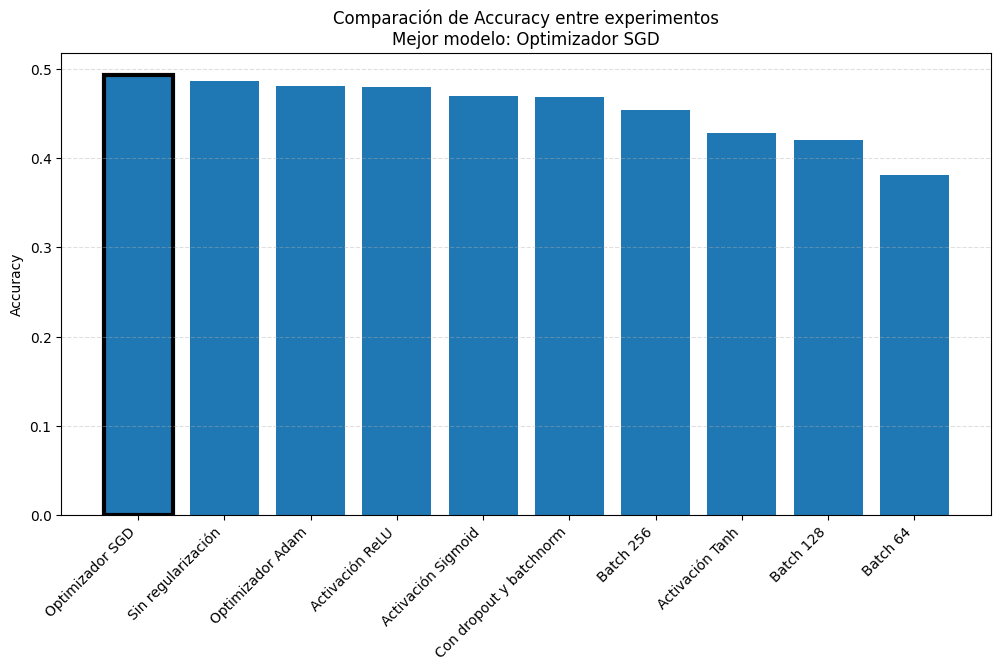

In [63]:
# Gráfico comparativo de accuracy

plt.figure(figsize=(12,6))
barras = plt.bar(df_resultados['Experimento'], df_resultados['Accuracy'])

for barra, experimento in zip(barras, df_resultados['Experimento']):
    if experimento == nombre_mejor_modelo:
        barra.set_edgecolor('black')
        barra.set_linewidth(3)

plt.xticks(rotation=45, ha='right')
plt.title(f'Comparación de Accuracy entre experimentos\nMejor modelo: {nombre_mejor_modelo}')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

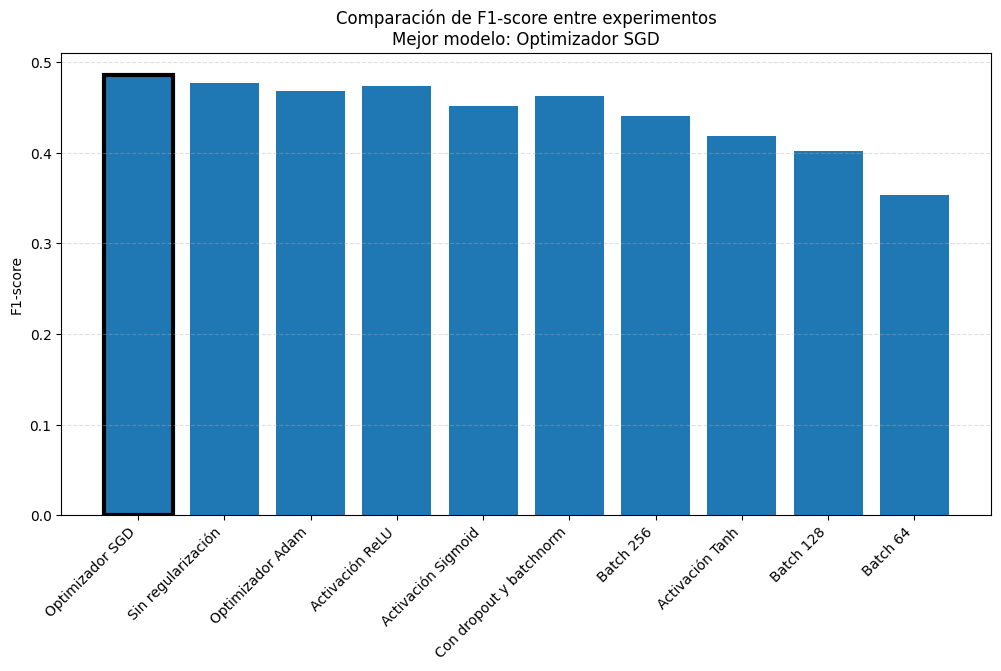

In [64]:
# Gráfico comparativo de F1-score

plt.figure(figsize=(12,6))
barras = plt.bar(df_resultados['Experimento'], df_resultados['F1-score'])

for barra, experimento in zip(barras, df_resultados['Experimento']):
    if experimento == nombre_mejor_modelo:
        barra.set_edgecolor('black')
        barra.set_linewidth(3)

plt.xticks(rotation=45, ha='right')
plt.title(f'Comparación de F1-score entre experimentos\nMejor modelo: {nombre_mejor_modelo}')
plt.ylabel('F1-score')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## Evaluación detallada del mejor modelo

Una vez identificado el mejor experimento, se evaluará nuevamente ese modelo utilizando el conjunto de prueba.

En esta sección se mostrará:
- el nombre del mejor modelo seleccionado,
- sus métricas principales,
- el reporte de clasificación,
- y la matriz de confusión.

Esto permite interpretar con mayor detalle el comportamiento final del experimento ganador.

In [65]:
# Diccionario de modelos entrenados para poder seleccionar dinámicamente el mejor

modelos_entrenados = {
    'Activación ReLU': modelo_relu,
    'Activación Sigmoid': modelo_sigmoid,
    'Activación Tanh': modelo_tanh,
    'Optimizador SGD': modelo_sgd,
    'Optimizador Adam': modelo_adam,
    'Batch 64': modelo_b64,
    'Batch 128': modelo_b128,
    'Batch 256': modelo_b256,
    'Sin regularización': modelo_sin_opt,
    'Con dropout y batchnorm': modelo_con_opt
}

nombre_mejor_modelo = mejor_fila['Experimento']
print("Mejor experimento según la tabla:", nombre_mejor_modelo)

mejor_modelo = modelos_entrenados[nombre_mejor_modelo]

Mejor experimento según la tabla: Optimizador SGD


In [66]:
# Evaluación detallada del mejor modelo

y_prob = mejor_modelo.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = labs_test.flatten()

accuracy_final = np.mean(y_pred == y_true)
precision_final = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_final = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_final = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("Mejor modelo seleccionado:", nombre_mejor_modelo)
print("Accuracy final:", round(accuracy_final, 4))
print("Precision final:", round(precision_final, 4))
print("Recall final:", round(recall_final, 4))
print("F1-score final:", round(f1_final, 4))

metricas_finales = pd.DataFrame({
    'Modelo': [nombre_mejor_modelo] * 4,
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Valor': [accuracy_final, precision_final, recall_final, f1_final]
})

metricas_finales

Mejor modelo seleccionado: Optimizador SGD
Accuracy final: 0.4928
Precision final: 0.5007
Recall final: 0.4928
F1-score final: 0.4858


,Modelo,Métrica,Valor
0,Optimizador SGD,Accuracy,0.492800
1,Optimizador SGD,Precision,0.500666
2,Optimizador SGD,Recall,0.492800
3,Optimizador SGD,F1-score,0.485784


### Interpretación de métricas

- **Accuracy** representa el porcentaje total de predicciones correctas realizadas por el modelo.
- **Precision** indica qué tan precisas son las predicciones del modelo al clasificar imágenes en las distintas categorías.
- **Recall** mide la capacidad del modelo para detectar correctamente los casos reales de cada clase.
- **F1-score** corresponde al equilibrio entre precision y recall, por lo que resulta especialmente útil para comparar modelos de clasificación.

Estas métricas permiten evaluar de forma más completa el comportamiento del modelo, más allá del accuracy.

In [67]:
# Reporte de clasificación del mejor modelo

print(f"Reporte de clasificación - {nombre_mejor_modelo}")
print(classification_report(y_true, y_pred, target_names=nombres, zero_division=0))

Reporte de clasificación - Optimizador SGD
              precision    recall  f1-score   support

       avión       0.59      0.51      0.55      1000
        auto       0.52      0.72      0.61      1000
      pájaro       0.36      0.40      0.38      1000
        gato       0.40      0.20      0.26      1000
      venado       0.41      0.46      0.43      1000
       perro       0.42      0.38      0.40      1000
        rana       0.46      0.65      0.54      1000
     caballo       0.50      0.63      0.56      1000
       barco       0.71      0.52      0.60      1000
      camión       0.63      0.47      0.53      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



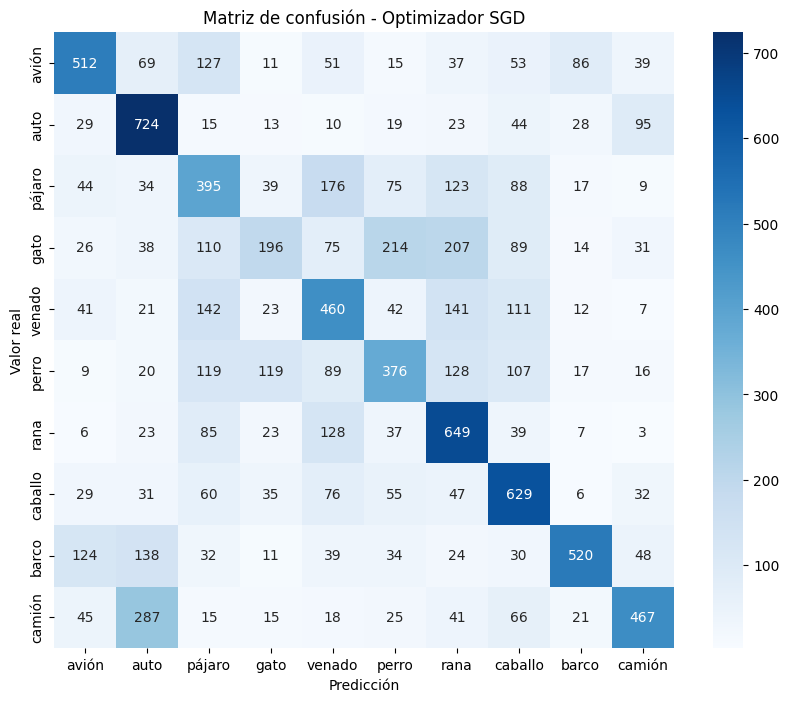

In [68]:
# Matriz de confusión del mejor modelo

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres, yticklabels=nombres)
plt.title(f'Matriz de confusión - {nombre_mejor_modelo}')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

## Análisis de resultados

A partir de los experimentos realizados, fue posible observar diferencias relevantes entre las distintas configuraciones evaluadas.

En el experimento de funciones de activación, se evidenció que el tipo de activación influye directamente en la convergencia y en el desempeño final del modelo. En general, algunas funciones mostraron un comportamiento más estable que otras, lo que confirma que la activación es un factor importante en el aprendizaje de una red MLP.

En la comparación de optimizadores, los resultados obtenidos en esta ejecución mostraron que **Optimizador SGD** alcanzó el mejor desempeño final dentro de las configuraciones evaluadas. Aunque optimizadores como Adam suelen ofrecer una convergencia rápida, en este caso específico el experimento con SGD obtuvo el mejor valor de accuracy según la tabla comparativa.

En el experimento de batch size, se comprobó que el tamaño del lote afecta la estabilidad del entrenamiento y el rendimiento final. Dependiendo de la configuración, algunos valores permiten una convergencia más estable que otros.

Finalmente, al comparar el modelo sin regularización con el modelo que incorpora dropout y batch normalization, se observó que estas técnicas influyen en la capacidad de generalización del modelo. Aunque no necesariamente produjeron el mejor accuracy final en esta ejecución, siguen siendo estrategias válidas para reducir el riesgo de overfitting.

En conjunto, los resultados muestran que la elección de hiperparámetros y técnicas de optimización tiene un impacto directo en el desempeño de una red neuronal MLP aplicada a clasificación de imágenes.

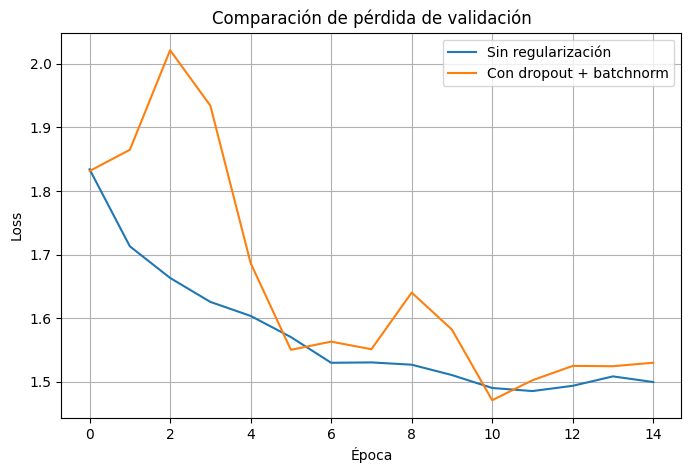

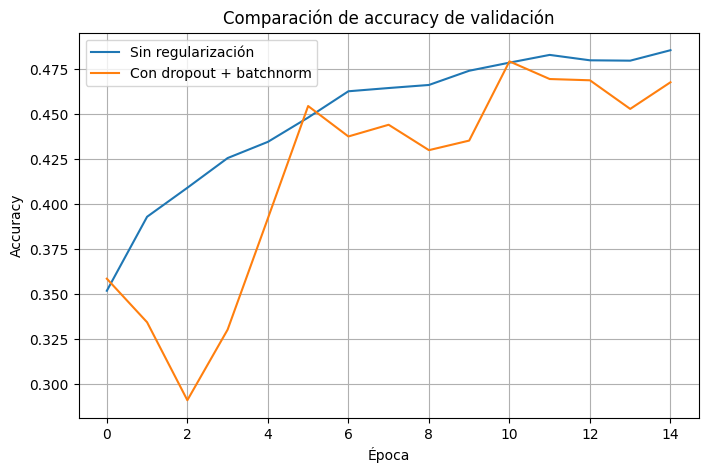

In [69]:
# Comparación visual entre el modelo sin regularización y el modelo con regularización

plt.figure(figsize=(8,5))
plt.plot(hist_sin_opt.history['val_loss'], label='Sin regularización')
plt.plot(hist_con_opt.history['val_loss'], label='Con dropout + batchnorm')
plt.title('Comparación de pérdida de validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(hist_sin_opt.history['val_accuracy'], label='Sin regularización')
plt.plot(hist_con_opt.history['val_accuracy'], label='Con dropout + batchnorm')
plt.title('Comparación de accuracy de validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Impacto de la optimización en la estabilidad del modelo

La comparación anterior permite observar cómo influyen las técnicas de regularización en el comportamiento del entrenamiento.

Cuando se incorpora **dropout** y **batch normalization**, el modelo tiende a comportarse de forma más estable, con una mejor capacidad de generalización y menor riesgo de sobreajuste.

Esto se evidencia cuando la curva de validación muestra un comportamiento más consistente y cercano al entrenamiento.

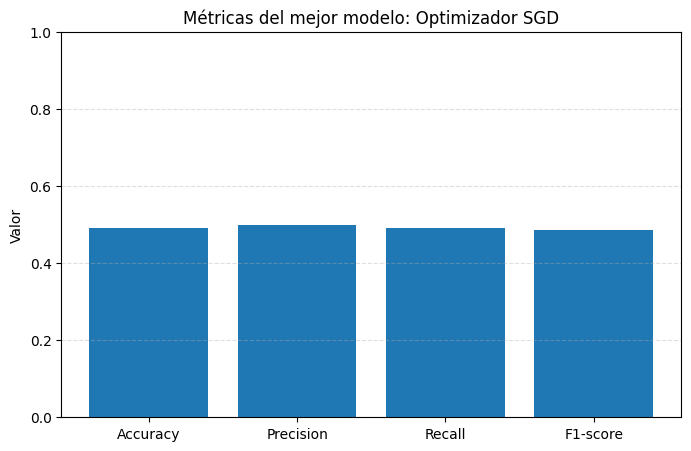

In [70]:
# Gráfico comparativo de métricas finales del mejor modelo

metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metricas_valores = [accuracy_final, precision_final, recall_final, f1_final]

plt.figure(figsize=(8,5))
plt.bar(metricas_nombres, metricas_valores)
plt.title(f'Métricas del mejor modelo: {nombre_mejor_modelo}')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## Cómo mejorar precision y recall

A partir de los resultados obtenidos, es posible proponer algunas estrategias para mejorar los valores de precision y recall del modelo:

- Ajustar hiperparámetros como el número de neuronas, épocas y batch size.
- Incorporar técnicas de regularización para reducir overfitting.
- Probar funciones de activación que favorezcan una convergencia más estable.
- Comparar distintas configuraciones de optimizadores.
- En trabajos futuros, utilizar arquitecturas más especializadas para imágenes, como redes convolucionales.

Estas mejoras permiten optimizar el equilibrio entre precisión global y capacidad de detección correcta de las clases.

## Conclusiones

En esta actividad se implementó una red neuronal artificial multicapa para clasificar imágenes del dataset CIFAR-10.

En primer lugar, se realizó la carga y el preprocesamiento de los datos, incluyendo la normalización de píxeles y el aplanamiento de imágenes para adaptarlas a la estructura de entrada del MLP. Posteriormente, se construyó un modelo base que sirvió como referencia para comparar distintas configuraciones.

Luego, se desarrollaron experimentos controlados variando un parámetro a la vez, lo que permitió analizar el impacto de las funciones de activación, optimizadores, tamaño de batch y técnicas de regularización.

De acuerdo con los resultados obtenidos en esta ejecución, el experimento que alcanzó el mejor desempeño fue **Optimizador SGD**. En este caso, la comparación permitió comprobar que la selección del optimizador y de los hiperparámetros influye de manera importante en el rendimiento final del modelo.

Además, se confirmó que métricas como accuracy, precision, recall y F1-score son fundamentales para evaluar de manera más completa el comportamiento del modelo y justificar técnicamente la elección de la mejor configuración.

Como mejora futura, sería posible comparar este MLP con arquitecturas más especializadas para imágenes, como redes neuronales convolucionales.

Es importante destacar que el uso de una red MLP presenta limitaciones para el procesamiento de imágenes, ya que no aprovecha la estructura espacial de los datos. Por esta razón, en trabajos futuros se recomienda el uso de redes neuronales convolucionales (CNN), las cuales suelen obtener mejores resultados en tareas de clasificación de imágenes.

## Decisiones técnicas adoptadas

Durante el desarrollo de este trabajo se tomaron las siguientes decisiones técnicas:

- Se utilizó **CIFAR-10** porque fue el dataset solicitado para la actividad.
- Se implementó una **red neuronal multicapa (MLP)**, ya que corresponde al tipo de red pedido en la evaluación.
- Se aplicó **normalización** para mejorar la estabilidad del entrenamiento.
- Se transformaron las imágenes a vectores de entrada debido a que un MLP no procesa imágenes en su forma matricial original.
- Se utilizó **softmax** en la capa de salida porque el problema corresponde a una clasificación multiclase.
- Se utilizó **categorical crossentropy** como función de pérdida por su compatibilidad con clasificación multiclase y etiquetas one-hot.
- Se probaron distintas funciones de activación, optimizadores y batch size para analizar su impacto.
- Se incorporaron **dropout** y **batch normalization** como técnicas para reducir overfitting y mejorar la generalización.

## Instrucciones para ejecutar el proyecto

Para ejecutar correctamente este cuaderno en Google Colab se deben seguir los siguientes pasos:

1. Abrir el archivo `.ipynb` en Google Colab.
2. Verificar que el entorno tenga instaladas las librerías necesarias:
   - TensorFlow
   - NumPy
   - Pandas
   - Matplotlib
   - Seaborn
   - Scikit-learn
3. Ejecutar las celdas en orden, desde la carga de librerías hasta las conclusiones.
4. Esperar a que finalicen los entrenamientos, ya que algunos experimentos pueden tardar varios minutos.
5. Revisar la tabla comparativa y los gráficos finales para identificar el mejor modelo.

## Referencias

- TensorFlow. (2024). *TensorFlow Documentation*. https://www.tensorflow.org/
- Keras. (2024). *Keras API Reference*. https://keras.io/
- CIFAR-10 Dataset. https://www.cs.toronto.edu/~kriz/cifar.html
- Scikit-learn. (2024). *Metrics Documentation*. https://scikit-learn.org/stable/modules/model_evaluation.html

## Cierre final

En síntesis, este trabajo permitió aplicar de forma práctica los fundamentos de Deep Learning mediante la implementación, entrenamiento, evaluación y análisis de una red neuronal multicapa para clasificación de imágenes.

La comparación de distintas configuraciones permitió respaldar técnicamente la elección del mejor modelo, que en esta ejecución correspondió a **Optimizador SGD**, y comprender cómo influyen distintos hiperparámetros y técnicas de optimización en el desempeño final del sistema.